# Notebook 06 -- Model Evaluation

## Data-Driven Framework for Early Detection of Alzheimer's Disease Using MRI Brain Images

---

### What This Notebook Does
1. Load the best model from `models/best_model.pth`
2. Run inference on the **test set** (never seen during training)
3. Generate **confusion matrix** heatmap
4. Compute **classification report** (precision, recall, F1 per class)
5. Visualize correct and incorrect predictions
6. Clinical interpretation of the results

### Why This Matters
- Validation accuracy tells us how the model does on data similar to training
- **Test set evaluation** is the true measure of generalization
- Per-class metrics reveal if the model struggles with rare classes (Moderate Dementia)

### Next Notebook
`07_model_saving_and_loading.ipynb` -- Production-ready inference pipeline.

## 1. Setup & Load Best Model

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score
)

sns.set_theme(style='whitegrid', font_scale=1.1)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [2]:
# ============ Load config ============
PROCESSED_DIR = Path("processed")
MODELS_DIR = Path("models")

with open(PROCESSED_DIR / 'preprocessing_config.json', 'r') as f:
    config = json.load(f)

IMG_SIZE = config['img_size']
NUM_CLASSES = config['num_classes']
CLASS_NAMES = config['class_names']
IDX_TO_CLASS = {i: name for i, name in enumerate(CLASS_NAMES)}
IMAGENET_MEAN = config['imagenet_mean']
IMAGENET_STD = config['imagenet_std']
NUM_WORKERS = 0  # Windows + Jupyter safe
BATCH_SIZE = 32

print(f"Classes: {CLASS_NAMES}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")

Classes: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
Image size: 128x128


In [3]:
# ============ Load best model checkpoint ============
checkpoint = torch.load(MODELS_DIR / 'best_model.pth', map_location=device, weights_only=False)
model_name = checkpoint['model_name']
best_val_acc = checkpoint['best_val_acc']

print(f"Best model: {model_name}")
print(f"Val accuracy: {best_val_acc:.2%}")

# ============ Recreate the model architecture ============
if model_name == 'resnet18':
    model = models.resnet18(weights=None)
    model.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(512, NUM_CLASSES))
elif model_name == 'efficientnet_b0':
    model = models.efficientnet_b0(weights=None)
    model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(1280, NUM_CLASSES))
elif model_name == 'vgg16':
    model = models.vgg16(weights=None)
    model.classifier[6] = nn.Sequential(nn.Dropout(0.3), nn.Linear(4096, NUM_CLASSES))
elif model_name == 'BaselineCNN' or model_name == 'baseline_cnn':
    # Recreate BaselineCNN
    class BaselineCNN(nn.Module):
        def __init__(self, num_classes=4):
            super().__init__()
            self.block1 = nn.Sequential(nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2,2))
            self.block2 = nn.Sequential(nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2,2))
            self.block3 = nn.Sequential(nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2,2))
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(128,64), nn.ReLU(True), nn.Dropout(0.5), nn.Linear(64,num_classes))
        def forward(self, x):
            x = self.block1(x); x = self.block2(x); x = self.block3(x); x = self.pool(x)
            return self.classifier(x)
    model = BaselineCNN(NUM_CLASSES)
else:
    raise ValueError(f"Unknown model: {model_name}")

model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()
print(f"\nModel loaded and set to evaluation mode.")
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")

Best model: resnet18
Val accuracy: 96.28%

Model loaded and set to evaluation mode.
Total params: 11,178,564


## 2. Load Test Dataset

In [4]:
class AlzheimerDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


# Test transforms (no augmentation)
test_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Load test split
test_df = pd.read_csv(PROCESSED_DIR / 'test_files.csv')
test_paths = test_df['path'].tolist()
test_labels = test_df['label'].tolist()

test_dataset = AlzheimerDataset(test_paths, test_labels, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

print(f"Test set: {len(test_dataset):,} images")
print(f"Test batches: {len(test_loader)}")
print(f"\nTest set class distribution:")
test_counts = Counter(test_labels)
for idx in sorted(test_counts.keys()):
    print(f"  {IDX_TO_CLASS[idx]:<25} {test_counts[idx]:>5} images")

Test set: 3,144 images
Test batches: 99

Test set class distribution:
  Mild Dementia               751 images
  Moderate Dementia            73 images
  Non Demented                262 images
  Very mild Dementia         2058 images


## 3. Run Inference on Test Set

In [5]:
all_preds = []
all_labels = []
all_probs = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

print(f"Inference complete on {len(all_preds):,} test images.")

Inference complete on 3,144 test images.


## 4. Overall Metrics

In [6]:
# ============ Compute overall metrics ============
test_accuracy = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average='macro')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
macro_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
macro_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)

print("=" * 50)
print(" TEST SET RESULTS")
print("=" * 50)
print(f"  Model:             {model_name}")
print(f"  Test Accuracy:     {test_accuracy:.2%}")
print(f"  Macro F1-Score:    {macro_f1:.4f}")
print(f"  Weighted F1-Score: {weighted_f1:.4f}")
print(f"  Macro Precision:   {macro_precision:.4f}")
print(f"  Macro Recall:      {macro_recall:.4f}")
print("=" * 50)

 TEST SET RESULTS
  Model:             resnet18
  Test Accuracy:     96.82%
  Macro F1-Score:    0.9635
  Weighted F1-Score: 0.9683
  Macro Precision:   0.9476
  Macro Recall:      0.9807


## 5. Classification Report (Per-Class Metrics)

In [7]:
# ============ Detailed classification report ============
report = classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
)
print("\nClassification Report:")
print("=" * 70)
print(report)

# Also save as dict for later use
report_dict = classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)


Classification Report:
                    precision    recall  f1-score   support

     Mild Dementia     0.9447    0.9547    0.9497       751
 Moderate Dementia     0.9359    1.0000    0.9669        73
      Non Demented     0.9258    1.0000    0.9615       262
Very mild Dementia     0.9842    0.9679    0.9760      2058

          accuracy                         0.9682      3144
         macro avg     0.9476    0.9807    0.9635      3144
      weighted avg     0.9688    0.9682    0.9683      3144



## 6. Confusion Matrix

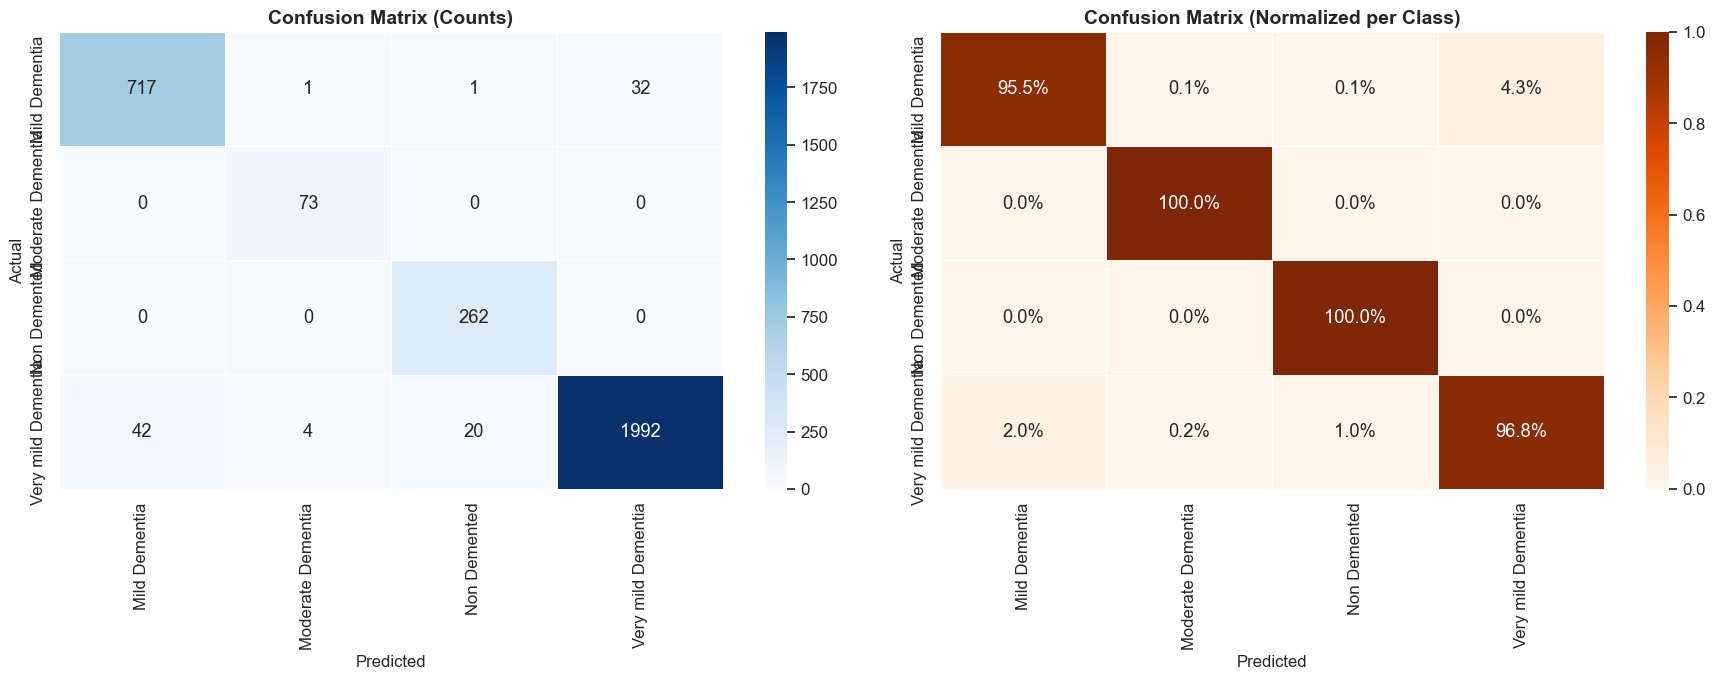

Saved as 'confusion_matrix.png'


In [8]:
# ============ Confusion Matrix (counts) ============
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)

# Normalized (percentages per row)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalized per Class)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as 'confusion_matrix.png'")

## 7. Per-Class Analysis

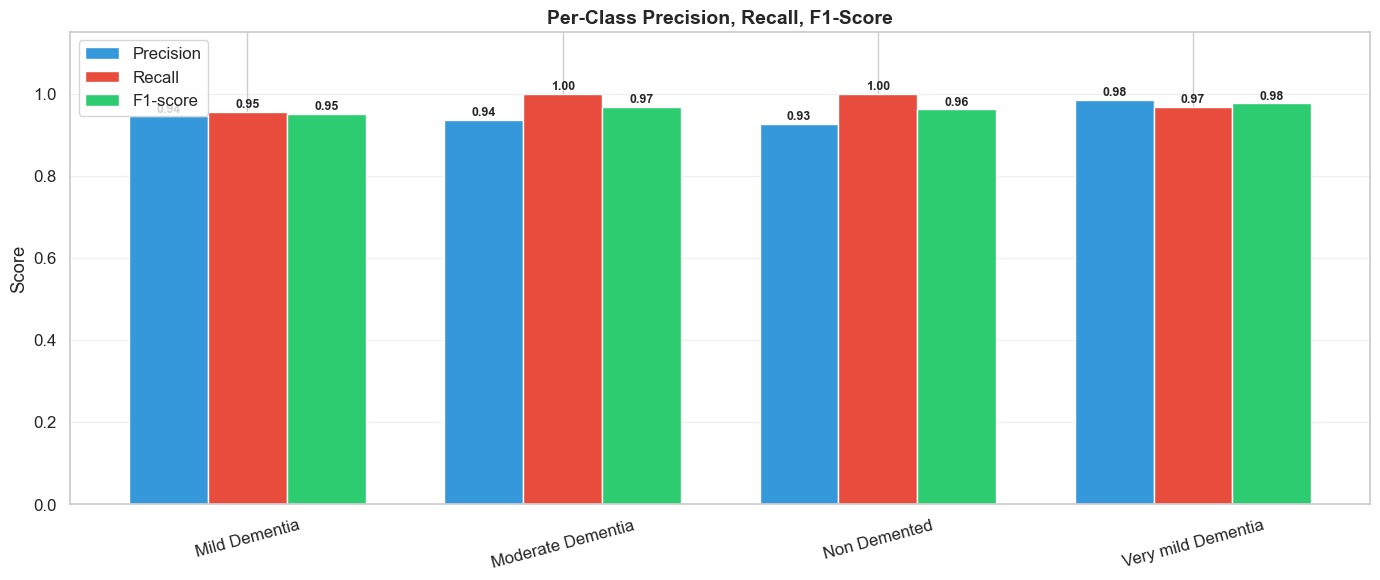

In [9]:
# ============ Per-class bar chart ============
metrics_names = ['precision', 'recall', 'f1-score']
x = np.arange(len(CLASS_NAMES))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
colors_bar = ['#3498db', '#e74c3c', '#2ecc71']

for i, metric in enumerate(metrics_names):
    values = [report_dict[cls][metric] for cls in CLASS_NAMES]
    bars = ax.bar(x + i * width, values, width, label=metric.capitalize(), color=colors_bar[i])
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(CLASS_NAMES, rotation=15)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.set_title('Per-Class Precision, Recall, F1-Score', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ============ Most confused class pairs ============
print("\nMost Common Misclassifications:")
print("=" * 60)

misclassified = []
for true_idx in range(NUM_CLASSES):
    for pred_idx in range(NUM_CLASSES):
        if true_idx != pred_idx and cm[true_idx][pred_idx] > 0:
            misclassified.append((
                IDX_TO_CLASS[true_idx],
                IDX_TO_CLASS[pred_idx],
                cm[true_idx][pred_idx]
            ))

misclassified.sort(key=lambda x: x[2], reverse=True)
for true_cls, pred_cls, count in misclassified[:10]:
    print(f"  {true_cls:<25} -> predicted as {pred_cls:<25} ({count} times)")


Most Common Misclassifications:
  Very mild Dementia        -> predicted as Mild Dementia             (42 times)
  Mild Dementia             -> predicted as Very mild Dementia        (32 times)
  Very mild Dementia        -> predicted as Non Demented              (20 times)
  Very mild Dementia        -> predicted as Moderate Dementia         (4 times)
  Mild Dementia             -> predicted as Moderate Dementia         (1 times)
  Mild Dementia             -> predicted as Non Demented              (1 times)


## 8. Visualize Correct & Incorrect Predictions

Correct:   3,044 / 3,144 (96.8%)
Incorrect: 100 / 3,144 (3.2%)


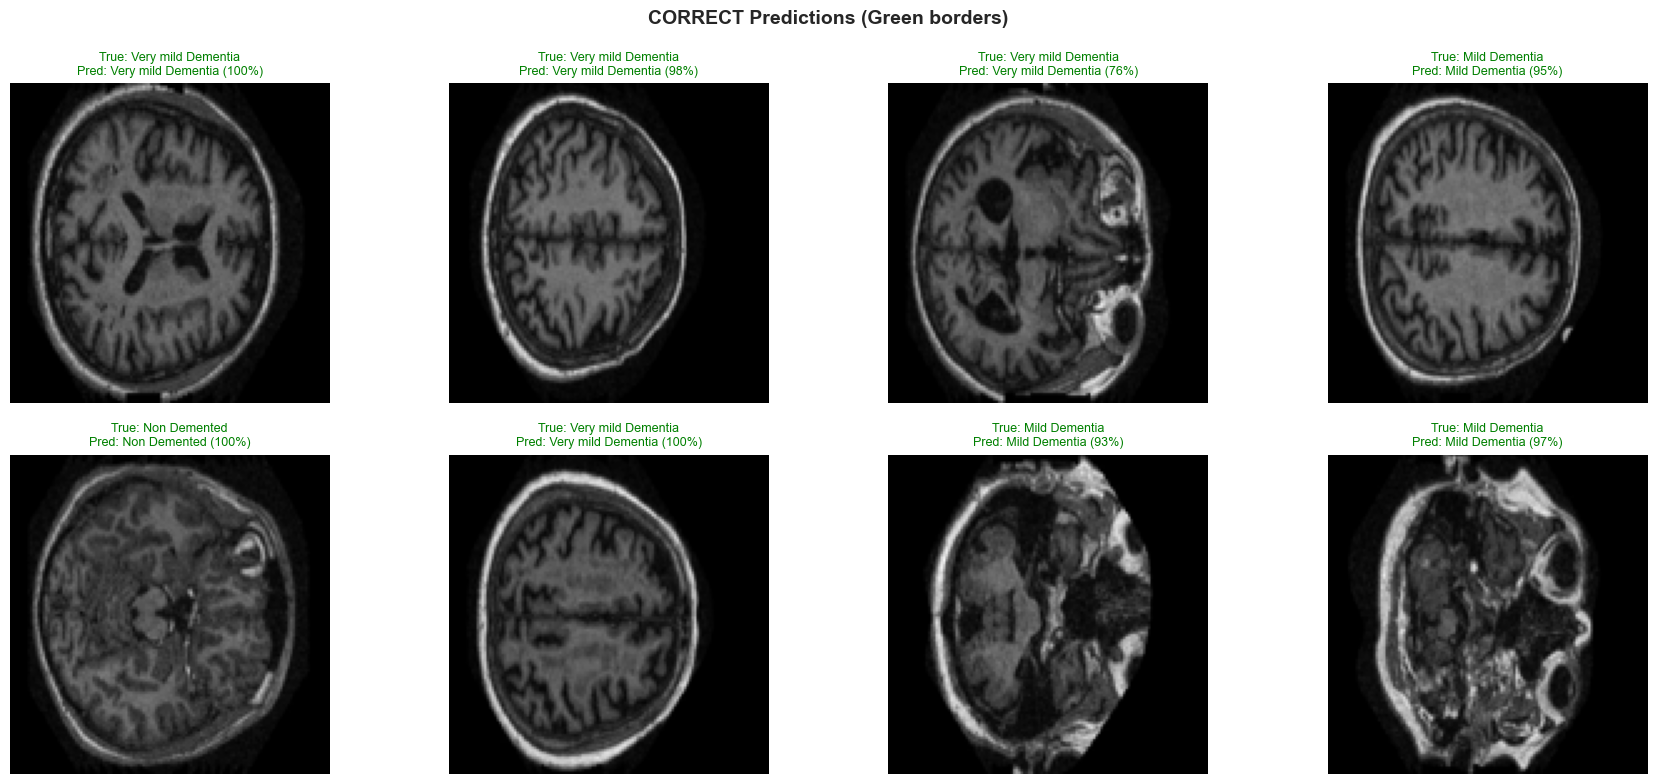

In [11]:
def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    t = tensor.clone()
    for ch, m, s in zip(t, mean, std):
        ch.mul_(s).add_(m)
    return torch.clamp(t, 0, 1)


# ============ Show correct predictions ============
correct_mask = all_preds == all_labels
incorrect_mask = ~correct_mask

print(f"Correct:   {correct_mask.sum():,} / {len(all_labels):,} ({correct_mask.mean():.1%})")
print(f"Incorrect: {incorrect_mask.sum():,} / {len(all_labels):,} ({incorrect_mask.mean():.1%})")

# Show 8 correct predictions
correct_indices = np.where(correct_mask)[0]
sample_correct = np.random.choice(correct_indices, min(8, len(correct_indices)), replace=False)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('CORRECT Predictions (Green borders)', fontsize=14, fontweight='bold')

for i, idx in enumerate(sample_correct):
    ax = axes[i // 4, i % 4]
    img = Image.open(test_paths[idx]).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    ax.imshow(img)
    conf = all_probs[idx][all_preds[idx]] * 100
    ax.set_title(f'True: {IDX_TO_CLASS[all_labels[idx]]}\nPred: {IDX_TO_CLASS[all_preds[idx]]} ({conf:.0f}%)',
                 fontsize=9, color='green')
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor('green')
        spine.set_linewidth(3)

plt.tight_layout()
plt.show()

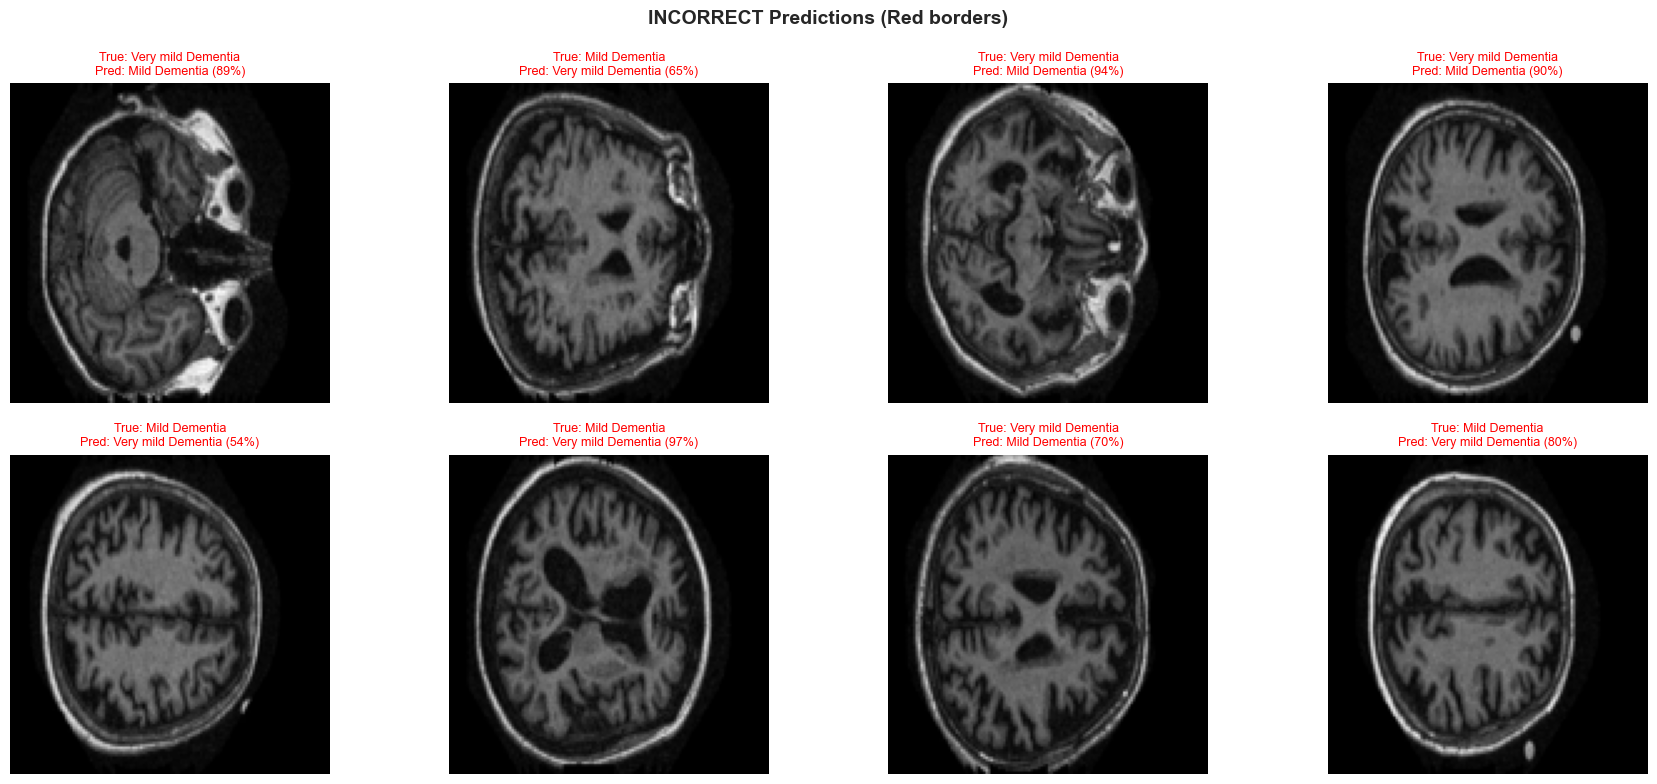

In [12]:
# ============ Show incorrect predictions ============
incorrect_indices = np.where(incorrect_mask)[0]

if len(incorrect_indices) > 0:
    sample_incorrect = np.random.choice(incorrect_indices, min(8, len(incorrect_indices)), replace=False)
    
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    fig.suptitle('INCORRECT Predictions (Red borders)', fontsize=14, fontweight='bold')
    
    for i, idx in enumerate(sample_incorrect):
        ax = axes[i // 4, i % 4]
        img = Image.open(test_paths[idx]).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        ax.imshow(img)
        conf = all_probs[idx][all_preds[idx]] * 100
        ax.set_title(f'True: {IDX_TO_CLASS[all_labels[idx]]}\nPred: {IDX_TO_CLASS[all_preds[idx]]} ({conf:.0f}%)',
                     fontsize=9, color='red')
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(3)
    
    # Hide unused subplots
    for j in range(len(sample_incorrect), 8):
        axes[j // 4, j % 4].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("No incorrect predictions! The model got 100% on the test set.")

## 9. Confidence Distribution

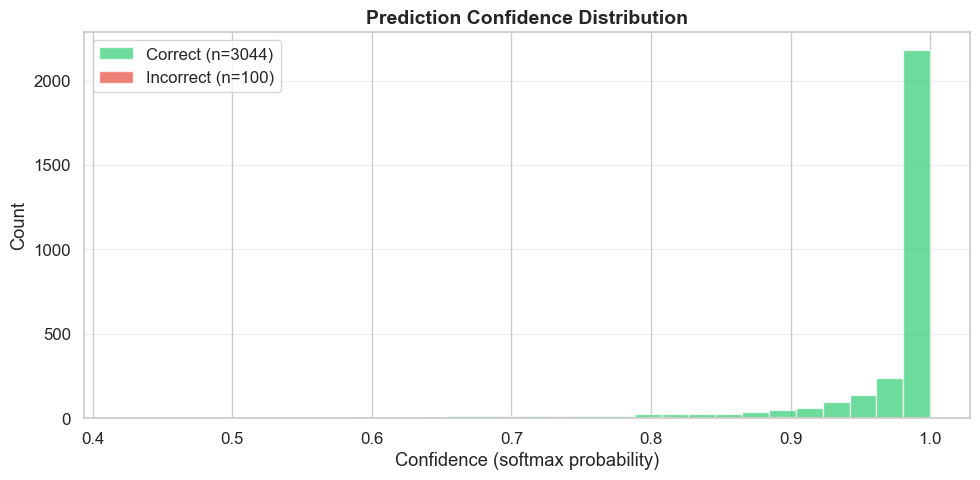


Avg confidence (correct):   0.964
Avg confidence (incorrect): 0.720


In [13]:
# ============ Confidence distribution for correct vs incorrect ============
correct_confs = [all_probs[i][all_preds[i]] for i in range(len(all_preds)) if all_preds[i] == all_labels[i]]
incorrect_confs = [all_probs[i][all_preds[i]] for i in range(len(all_preds)) if all_preds[i] != all_labels[i]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(correct_confs, bins=30, alpha=0.7, label=f'Correct (n={len(correct_confs)})', color='#2ecc71')
if len(incorrect_confs) > 0:
    ax.hist(incorrect_confs, bins=30, alpha=0.7, label=f'Incorrect (n={len(incorrect_confs)})', color='#e74c3c')
ax.set_title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Confidence (softmax probability)')
ax.set_ylabel('Count')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAvg confidence (correct):   {np.mean(correct_confs):.3f}")
if len(incorrect_confs) > 0:
    print(f"Avg confidence (incorrect): {np.mean(incorrect_confs):.3f}")

## 10. Save Evaluation Results

In [14]:
# ============ Save results to JSON ============
eval_results = {
    'model_name': model_name,
    'test_accuracy': float(test_accuracy),
    'macro_f1': float(macro_f1),
    'weighted_f1': float(weighted_f1),
    'macro_precision': float(macro_precision),
    'macro_recall': float(macro_recall),
    'per_class_report': report_dict,
    'confusion_matrix': cm.tolist(),
    'test_size': len(test_labels)
}

results_path = MODELS_DIR / 'evaluation_results.json'
with open(results_path, 'w') as f:
    json.dump(eval_results, f, indent=2)

print(f"Evaluation results saved to: {results_path}")

Evaluation results saved to: models\evaluation_results.json


## 11. Clinical Interpretation

### What the Results Mean

**For a medical AI system, we care most about:**
1. **Recall for Moderate Dementia** -- Can the model detect severe cases? Missing them is dangerous.
2. **Recall for Mild Dementia** -- Early detection is the whole point.
3. **Precision for Non Demented** -- False positives (healthy people told they have dementia) cause unnecessary anxiety.

### Common Confusion Patterns
- **Non Demented <-> Very Mild Dementia**: These are clinically very similar. Even human radiologists struggle here.
- **Mild <-> Very Mild**: Subtle differences in brain atrophy patterns.
- **Moderate Dementia**: Often misclassified due to very few training samples (~64 total).

### Limitations
- The model is trained on 2D MRI slices, not full 3D brain volumes
- Moderate Dementia class has very few samples -- results for this class are unreliable
- This is NOT a clinical diagnostic tool -- it's a research/educational project

---

### Summary
- Evaluated best model on held-out test set
- Generated confusion matrix and per-class metrics
- Visualized correct and incorrect predictions
- Analyzed confidence distributions
- Saved evaluation results

### Next Step
-> **Notebook 07** (`07_model_saving_and_loading.ipynb`): Create a clean inference pipeline.

---
*End of Notebook 06*